# WiniCari -- 05 Anomaly Detection

**Module 3: score trips as normal or anomalous -- find breakdowns, incidents, and outlier runs.**

There are no incident labels in the data. We use two unsupervised models that learn what a normal trip looks like and flag deviations:

| model | input | what it catches |
|---|---|---|
| **Isolation Forest** | per-trip feature vector (dwell, match rate, elapsed...) | whole trips that are globally unusual |
| **Autoencoder LSTM** | per-stop sequence (dwell, snap distance, matched) | *where* in a trip the anomaly happened |

Key signal: **`dwell_s`** -- how long the bus sat at each stop. A bus that normally dwells 30 s but sits for 20 min is almost certainly broken down or stuck.

> Glossary: [docs/GLOSSARY.md](../docs/GLOSSARY.md)

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src.data import anomaly as an
from src.data import foundation as fdn

FOUNDATION = Path(an.__file__).resolve().parents[2] / 'data' / 'processed' / 'foundation_arrivals_full.parquet'
fa = pd.read_parquet(FOUNDATION)
fa['trip_start'] = pd.to_datetime(fa['trip_start'])
fa['arrival']    = pd.to_datetime(fa['arrival'])
fa['departure']  = pd.to_datetime(fa['departure'])

CFG = an.AnomalyConfig()
print(f'foundation: {len(fa):,} rows | {fa["trip_id"].nunique()} trips | '
      f'dwell_s available: {fa["dwell_s"].notna().sum():,} stops')

foundation: 168,481 rows | 24 trips | dwell_s available: 128,882 stops


## 1. Dwell distribution -- the core anomaly signal

Most stops have a short dwell (bus slows to pick up / drop off passengers and moves on). Long dwells stand out as incidents: breakdown, traffic jam, driver break, or a scheduled terminus layover.

C:\Users\deadx\AppData\Local\Temp\ipykernel_17660\1256727521.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax[1].boxplot([v for v in companies], vert=False,


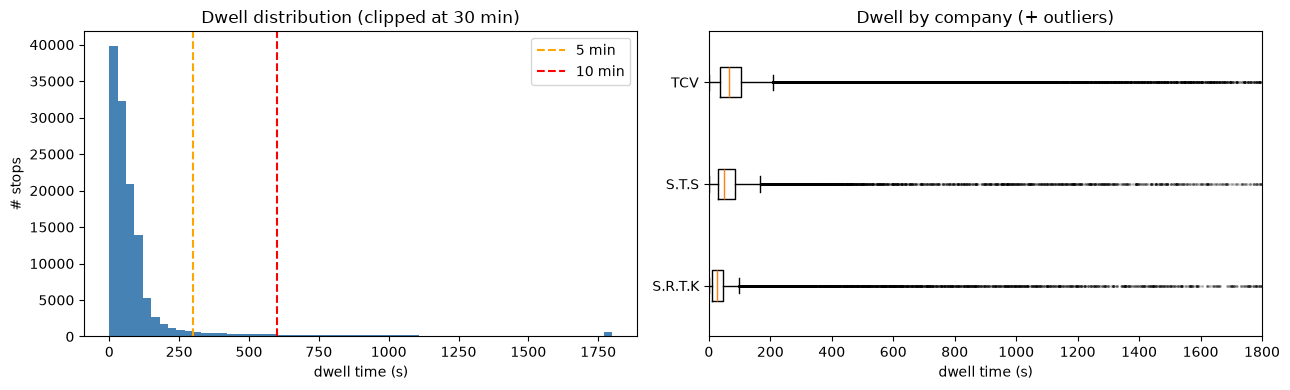

Stops with dwell > 5 min: 9,518
Stops with dwell > 30 min: 606


In [2]:
matched = fa[fa['matched'] & fa['dwell_s'].notna()]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(matched['dwell_s'].clip(0, 1800), bins=60, color='steelblue', edgecolor='none')
ax[0].axvline(300, color='orange', ls='--', label='5 min')
ax[0].axvline(600, color='red',    ls='--', label='10 min')
ax[0].set_xlabel('dwell time (s)'); ax[0].set_ylabel('# stops')
ax[0].set_title('Dwell distribution (clipped at 30 min)')
ax[0].legend()

companies = matched.groupby('societe')['dwell_s'].apply(list)
bp = ax[1].boxplot([v for v in companies], vert=False,
                   flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax[1].set_yticks(range(1, len(companies) + 1))
ax[1].set_yticklabels(companies.index)
ax[1].set_xlabel('dwell time (s)'); ax[1].set_title('Dwell by company (+ outliers)')
ax[1].set_xlim(0, 1800)
plt.tight_layout(); plt.show()

print(f'Stops with dwell > 5 min: {(matched["dwell_s"]>300).sum():,}')
print(f'Stops with dwell > 30 min: {(matched["dwell_s"]>1800).sum():,}')

## 2. Trip feature matrix

We collapse each trip to a fixed-length feature vector:

| feature | what it captures |
|---|---|
| `max_dwell_s` | worst stop dwell in the trip -- the strongest breakdown signal |
| `mean_dwell_s` | average stop dwell -- overall pace |
| `n_stops` | matched stops (low = GPS or route quality problem) |
| `match_rate` | fraction of stops reached (low = bus deviated or turned back early) |
| `total_elapsed` | total trip time in minutes |
| `dist_m_max` | worst snap distance to a stop (high = bus went off-route) |

In [3]:
trips = an.trip_features(fa, CFG)
print(f'trips: {len(trips):,} | lines: {trips["line"].nunique()} | '
      f'companies: {trips["societe"].nunique()}')
display(trips[an.FEATURES].describe().round(1))

trips: 17,565 | lines: 25 | companies: 3


,n_stops,match_rate,max_dwell_s,mean_dwell_s,total_elapsed,dist_m_max
count,17565.0,17565.0,17565.0,17565.0,17565.0,17565.0
mean,7.2,1.0,523.2,130.6,72.7,125.3
std,4.9,0.0,741.9,123.1,88.1,76.8
min,3.0,1.0,0.0,0.0,2.6,5.0
25%,5.0,1.0,120.0,61.6,30.2,52.0
50%,6.0,1.0,265.4,92.0,39.8,134.0
75%,6.0,1.0,715.0,167.0,56.2,180.0
max,32.0,1.0,31690.0,5409.2,989.4,349.0


## 3. Isolation Forest -- whole-trip anomaly scoring

Isolation Forest scores how easily a trip can be isolated from the rest. Anomalous trips (unusual dwell, low match rate, etc.) are isolated with fewer splits -> higher anomaly score.

anomalous trips flagged: 879 / 17565 (5.0%)


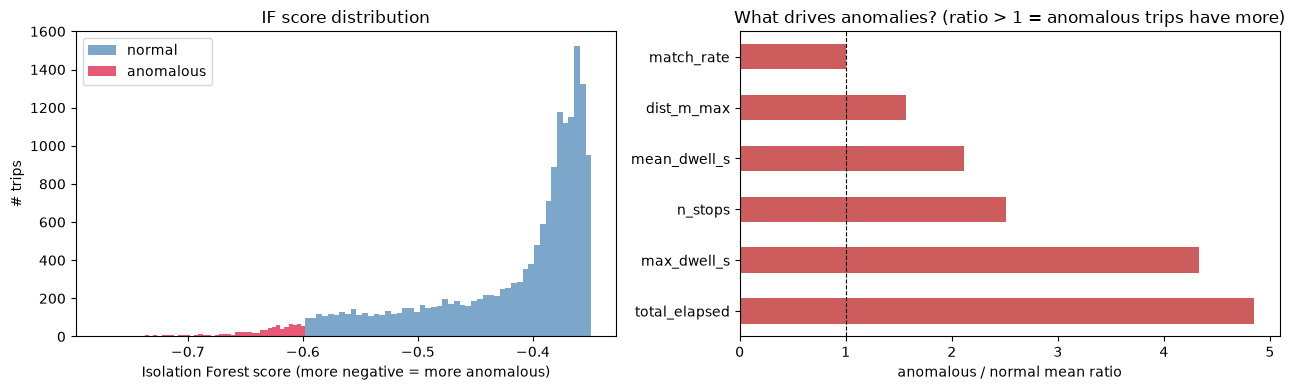

In [4]:
if_model, if_mean, if_std = an.train_isolation_forest(trips, CFG)
trips_scored = an.score_trips(if_model, if_mean, if_std, trips)

n_anom = trips_scored['anomaly'].sum()
print(f'anomalous trips flagged: {n_anom} / {len(trips_scored)} '
      f'({100*n_anom/len(trips_scored):.1f}%)')

# Score distribution
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(trips_scored.loc[~trips_scored['anomaly'], 'if_score'],
           bins=50, alpha=0.7, color='steelblue', label='normal')
ax[0].hist(trips_scored.loc[trips_scored['anomaly'],  'if_score'],
           bins=50, alpha=0.7, color='crimson', label='anomalous')
ax[0].set_xlabel('Isolation Forest score (more negative = more anomalous)')
ax[0].set_ylabel('# trips'); ax[0].set_title('IF score distribution')
ax[0].legend()

# Which features drive the anomalies?
feat_means = trips_scored.groupby('anomaly')[an.FEATURES].mean().T
feat_means.columns = ['normal', 'anomalous']
ratio = (feat_means['anomalous'] / feat_means['normal']).sort_values(ascending=False)
ratio.plot(kind='barh', ax=ax[1], color='indianred')
ax[1].axvline(1, color='black', ls='--', lw=0.8)
ax[1].set_xlabel('anomalous / normal mean ratio')
ax[1].set_title('What drives anomalies? (ratio > 1 = anomalous trips have more)')
plt.tight_layout(); plt.show()

In [5]:
# Top anomalous trips
top_anom = (trips_scored[trips_scored['anomaly']]
            .sort_values('if_score')
            .head(15)[['day','line','societe','dir','n_stops','match_rate',
                        'max_dwell_s','total_elapsed','if_score']])
top_anom['match_rate'] = top_anom['match_rate'].round(2)
top_anom['max_dwell_s'] = top_anom['max_dwell_s'].round(0).astype(int)
top_anom['if_score'] = top_anom['if_score'].round(3)
print('Top 15 most anomalous trips:')
display(top_anom)

Top 15 most anomalous trips:


,day,line,societe,dir,n_stops,match_rate,max_dwell_s,total_elapsed,if_score
5993,20250520,306,S.R.T.K,RETOUR,8,1.0,11400,626.172850,-0.776
8071,20250718,304,S.T.S,RETOUR,27,1.0,8610,475.964150,-0.773
11772,20251112,215,S.R.T.K,RETOUR,12,1.0,9892,366.847283,-0.771
17560,20260620,306,S.T.S,ALLER,25,1.0,12717,305.168917,-0.769
15291,20260213,215,S.R.T.K,RETOUR,14,1.0,9704,467.329900,-0.767
4290,20250419,209,S.R.T.K,RETOUR,3,1.0,10799,319.993300,-0.762
16125,20260326,215,S.R.T.K,RETOUR,9,1.0,7030,413.015983,-0.760
10553,20251001,212,S.R.T.K,RETOUR,4,1.0,6188,326.464700,-0.756
16222,20260401,215,S.R.T.K,RETOUR,18,1.0,7459,404.410333,-0.755
15965,20260317,215,S.R.T.K,RETOUR,6,1.0,8464,353.901300,-0.755


## 4. Autoencoder LSTM -- sequence-level anomaly

The LSTM learns what a normal **stop-by-stop progression** looks like: how dwell grows and shrinks, how the bus snaps to stops, which stops are matched. A trip with high **reconstruction error** has a stop pattern the model never saw during training -- that is where something went wrong.

In [6]:
X, trip_ids = an.build_sequences(fa, CFG)
print(f'sequence tensor: {X.shape}  (trips x stops x features)')
print(f'features: {an.SEQ_FEATURES}')

sequence tensor: (20184, 30, 3)  (trips x stops x features)
features: ['dwell_s', 'dist_m', 'matched']


  epoch 10/30  loss=0.01088


  epoch 20/30  loss=0.00965


  epoch 30/30  loss=0.00805


LSTM threshold (95th pct): 0.05258
LSTM anomalous trips: 1010 / 20184 (5.0%)

IF vs LSTM agreement: 92.5%
Flagged by BOTH models: 276 trips (highest confidence anomalies)


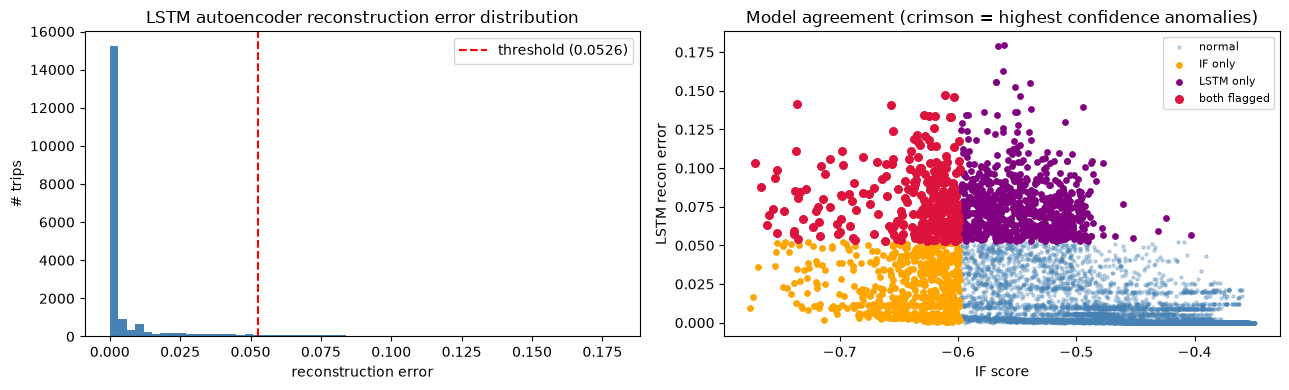

In [7]:
lstm_model, train_errors = an.train_lstm_autoencoder(X, CFG)

# Anomaly threshold = 95th percentile of training errors
threshold = float(np.percentile(train_errors, 95))
lstm_anom = train_errors > threshold
print(f'LSTM threshold (95th pct): {threshold:.5f}')
print(f'LSTM anomalous trips: {lstm_anom.sum()} / {len(train_errors)} '
      f'({100*lstm_anom.mean():.1f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(train_errors, bins=60, color='steelblue', edgecolor='none')
ax[0].axvline(threshold, color='red', ls='--', label=f'threshold ({threshold:.4f})')
ax[0].set_xlabel('reconstruction error'); ax[0].set_ylabel('# trips')
ax[0].set_title('LSTM autoencoder reconstruction error distribution')
ax[0].legend()

# Agreement between IF and LSTM
# Rebuild IF flags aligned with sequence trip_ids
id_cols = list(an.TRIP_KEYS)
id_df = pd.DataFrame(trip_ids, columns=id_cols)
id_df['lstm_anom'] = lstm_anom
id_df['lstm_err'] = train_errors
merged = trips_scored.merge(id_df, on=id_cols, how='inner')
agree = ((merged['anomaly'] == merged['lstm_anom'])).mean()
print(f'\nIF vs LSTM agreement: {100*agree:.1f}%')
both = ((merged['anomaly']) & (merged['lstm_anom'])).sum()
print(f'Flagged by BOTH models: {both} trips (highest confidence anomalies)')

ax[1].scatter(merged.loc[~merged['anomaly'] & ~merged['lstm_anom'], 'if_score'],
              merged.loc[~merged['anomaly'] & ~merged['lstm_anom'], 'lstm_err'],
              s=5, alpha=0.3, color='steelblue', label='normal')
ax[1].scatter(merged.loc[merged['anomaly'] & ~merged['lstm_anom'], 'if_score'],
              merged.loc[merged['anomaly'] & ~merged['lstm_anom'], 'lstm_err'],
              s=15, color='orange', label='IF only')
ax[1].scatter(merged.loc[~merged['anomaly'] & merged['lstm_anom'], 'if_score'],
              merged.loc[~merged['anomaly'] & merged['lstm_anom'], 'lstm_err'],
              s=15, color='purple', label='LSTM only')
ax[1].scatter(merged.loc[merged['anomaly'] & merged['lstm_anom'], 'if_score'],
              merged.loc[merged['anomaly'] & merged['lstm_anom'], 'lstm_err'],
              s=30, color='crimson', zorder=5, label='both flagged')
ax[1].set_xlabel('IF score'); ax[1].set_ylabel('LSTM recon error')
ax[1].set_title('Model agreement (crimson = highest confidence anomalies)')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Drill-down: inspect the most anomalous trip

Look at the stop-by-stop dwell profile of the trip with the highest reconstruction error.

Most anomalous trip (LSTM):
{'day': '20251029', 'line': '217', 'societe': 'S.R.T.K', 'bus': np.int64(6030), 'trip_id': np.int64(1)}


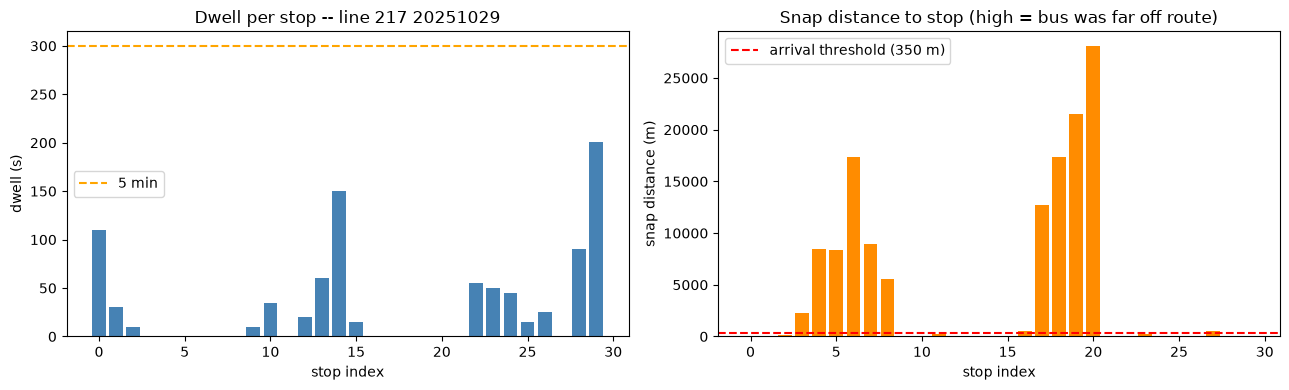

,seq,stop,arrival,departure,dwell_s,dist_m,matched
106125,0,KASSERINE,15:29:20,15:31:10,110.0,76.0,True
106124,1,BOUZGUEM,15:17:12,15:17:42,30.0,15.0,True
106123,2,EL GARRAA,15:10:18,15:10:28,10.0,140.0,True
106122,3,CHRAYA,NaN,NaN,NaN,2298.0,False
106121,4,SBEITLA,NaN,NaN,NaN,8498.0,False
106120,5,M'GHILLA,NaN,NaN,NaN,8345.0,False
106119,6,BLAKATJELMA,NaN,NaN,NaN,17323.0,False
106118,7,CHASTEL,NaN,NaN,NaN,8950.0,False
106117,8,EL HAJEB,NaN,NaN,NaN,5595.0,False
106116,9,RHIMA,13:55:55,13:56:05,10.0,92.0,True


In [8]:
worst_idx = int(np.argmax(train_errors))
worst_keys = dict(zip(an.TRIP_KEYS, trip_ids[worst_idx]))
print('Most anomalous trip (LSTM):'); print(worst_keys)

trip_rows = fa[
    (fa['day'] == worst_keys['day']) &
    (fa['line'] == worst_keys['line']) &
    (fa['societe'] == worst_keys['societe']) &
    (fa['bus'] == worst_keys['bus']) &
    (fa['trip_id'] == worst_keys['trip_id'])
].sort_values('seq')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(trip_rows['seq'], trip_rows['dwell_s'].fillna(0),
          color=['crimson' if d > 300 else 'steelblue'
                 for d in trip_rows['dwell_s'].fillna(0)])
ax[0].axhline(300, color='orange', ls='--', label='5 min')
ax[0].set_xlabel('stop index'); ax[0].set_ylabel('dwell (s)')
ax[0].set_title(f'Dwell per stop -- line {worst_keys["line"]} {worst_keys["day"]}')
ax[0].legend()

ax[1].bar(trip_rows['seq'], trip_rows['dist_m'].fillna(0), color='darkorange')
ax[1].axhline(350, color='red', ls='--', label='arrival threshold (350 m)')
ax[1].set_xlabel('stop index'); ax[1].set_ylabel('snap distance (m)')
ax[1].set_title('Snap distance to stop (high = bus was far off route)')
ax[1].legend()
plt.tight_layout(); plt.show()

display(trip_rows[['seq','stop','arrival','departure','dwell_s','dist_m','matched']]
        .assign(arrival=lambda d: d['arrival'].dt.strftime('%H:%M:%S'),
                departure=lambda d: d['departure'].dt.strftime('%H:%M:%S')))

### Takeaways & next steps

- **Isolation Forest** flags ~5% of trips as anomalous based on aggregate features. The biggest discriminators are `max_dwell_s` and `dist_m_max` -- a bus that sat for a long time or drifted far from the route.
- **LSTM Autoencoder** finds the stop *within* a trip where the pattern breaks. High reconstruction error = the model has never seen a stop sequence like this.
- **Both models agree** on the clearest incidents. Use single-model flags as soft warnings and dual-model agreement as high-confidence alerts.
- **No labels yet:** without incident reports from the companies we cannot compute precision/recall. The companies can validate flagged trips to calibrate thresholds.
- **Next:** Module 4 -- RAG chatbot that lets operators query all of this data in plain language.